In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv("dataset\SuperStoreOrders.csv")

In [47]:
# Check nulls in each column
null_counts = df.isnull().sum()

print(null_counts)

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


In [48]:
df.dtypes

order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region             object
product_id         object
category           object
sub_category       object
product_name       object
sales              object
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object
year                int64
dtype: object

In [49]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [50]:
df['order_date'].head(10)

0   2011-01-01
1   2011-01-01
2   2011-01-01
3   2011-01-01
4   2011-01-01
5   2011-01-01
6   2011-01-02
7   2011-01-03
8   2011-01-03
9   2011-01-03
Name: order_date, dtype: datetime64[ns]

In [51]:
# Check nulls again after coercion
print(df.isnull().sum())

order_id             0
order_date           0
ship_date            0
ship_mode            0
customer_name        0
segment              0
state                0
country              0
market               0
region               0
product_id           0
category             0
sub_category         0
product_name         0
sales             2630
quantity             0
discount             0
profit               0
shipping_cost        0
order_priority       0
year                 0
dtype: int64


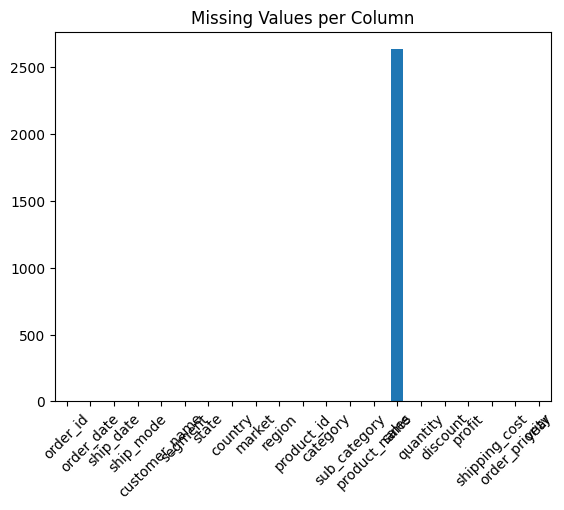

In [52]:
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values per Column")
plt.xticks(rotation=45)
plt.show()

In [53]:
#Remove null values from sales
df = df.dropna(subset=['sales'])

In [54]:
df['month'] = df['order_date'].dt.month

df['profit_margin'] = df['profit'] / df['sales']

df['profit_margin'] = df['profit_margin'].replace([float('inf'), -float('inf')], 0) #Handle division issues

In [55]:
avg_profit_margin = df['profit_margin'].mean()
print("Average Profit Margin:", avg_profit_margin)

Average Profit Margin: 0.0419385808037921


In [56]:
negative_margins = df[df['profit_margin'] < 0]

print("Number of negative profit rows:", len(negative_margins))
print(negative_margins[['sales', 'profit', 'profit_margin']].head())

Number of negative profit rows: 12107
    sales    profit  profit_margin
3    45.0  -26.0550      -0.579000
8   912.0 -319.4640      -0.350289
10  338.0 -122.8005      -0.363315
11  211.0  -70.3995      -0.333647
14  159.0  -95.6760      -0.601736


In [57]:
profit_by_category = df.groupby('category')['profit_margin'].mean().sort_values(ascending=False)

print(profit_by_category)

category
Office Supplies    0.056964
Technology         0.033307
Furniture         -0.001175
Name: profit_margin, dtype: float64


In [58]:
profit_by_region = df.groupby('region')['profit_margin'].mean().sort_values(ascending=False)

print(profit_by_region)

region
Canada            0.245238
West              0.222784
North Asia        0.177879
East              0.169768
Central Asia      0.143957
North             0.121891
Oceania           0.080064
Caribbean         0.078438
Central           0.056557
South             0.049675
Southeast Asia   -0.088479
EMEA             -0.149067
Africa           -0.156644
Name: profit_margin, dtype: float64


In [59]:
profit_vs_shipping = df[['shipping_cost', 'profit_margin']]

# Correlation
correlation = df['shipping_cost'].corr(df['profit_margin'])

print("Correlation between Shipping Cost and Profit Margin:", correlation)

Correlation between Shipping Cost and Profit Margin: 0.06662782964264964


In [60]:
df['order_date'] = pd.to_datetime(df['order_date'])

monthly_profit = df.groupby(df['order_date'].dt.to_period('M'))['profit_margin'].mean()

print(monthly_profit)

order_date
2011-01   -0.015090
2011-02    0.032617
2011-03    0.076361
2011-04    0.046615
2011-05    0.033786
2011-06   -0.023988
2011-07    0.020331
2011-08    0.042371
2011-09    0.070058
2011-10    0.047238
2011-11    0.032570
2011-12    0.031080
2012-01    0.032255
2012-02    0.019262
2012-03    0.015452
2012-04    0.040460
2012-05    0.035243
2012-06    0.025125
2012-07    0.016469
2012-08    0.058313
2012-09    0.047332
2012-10    0.070075
2012-11    0.032789
2012-12    0.068263
2013-01    0.043258
2013-02    0.043840
2013-03    0.026958
2013-04    0.013007
2013-05    0.051592
2013-06    0.050123
2013-07    0.057021
2013-08    0.031953
2013-09    0.051376
2013-10    0.045095
2013-11    0.076557
2013-12    0.039106
2014-01    0.045083
2014-02    0.018947
2014-03    0.058394
2014-04    0.009342
2014-05    0.037009
2014-06    0.035423
2014-07    0.022637
2014-08    0.072943
2014-09    0.063169
2014-10    0.046441
2014-11    0.053677
2014-12    0.023337
Freq: M, Name: profit_margin,

In [61]:
monthly_profit.index = monthly_profit.index.to_timestamp()

In [62]:
monthly_profit.index

DatetimeIndex(['2011-01-01', '2011-02-01', '2011-03-01', '2011-04-01',
               '2011-05-01', '2011-06-01', '2011-07-01', '2011-08-01',
               '2011-09-01', '2011-10-01', '2011-11-01', '2011-12-01',
               '2012-01-01', '2012-02-01', '2012-03-01', '2012-04-01',
               '2012-05-01', '2012-06-01', '2012-07-01', '2012-08-01',
               '2012-09-01', '2012-10-01', '2012-11-01', '2012-12-01',
               '2013-01-01', '2013-02-01', '2013-03-01', '2013-04-01',
               '2013-05-01', '2013-06-01', '2013-07-01', '2013-08-01',
               '2013-09-01', '2013-10-01', '2013-11-01', '2013-12-01',
               '2014-01-01', '2014-02-01', '2014-03-01', '2014-04-01',
               '2014-05-01', '2014-06-01', '2014-07-01', '2014-08-01',
               '2014-09-01', '2014-10-01', '2014-11-01', '2014-12-01'],
              dtype='datetime64[ns]', name='order_date', freq='MS')

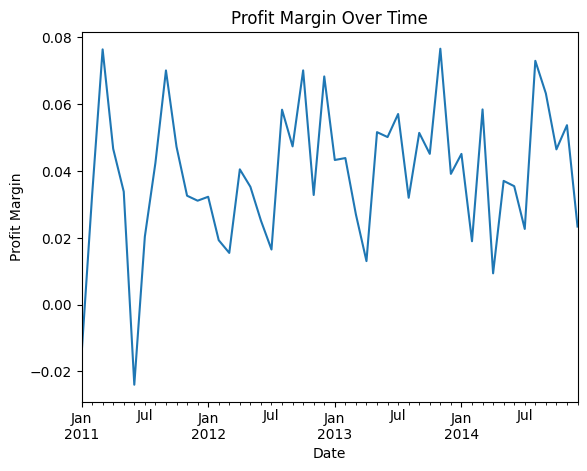

In [63]:
monthly_profit.plot()
plt.title("Profit Margin Over Time")
plt.xlabel("Date")
plt.ylabel("Profit Margin")
plt.show()

In [64]:
print(df['profit_margin'].mean())

0.0419385808037921


In [65]:
print((df['profit_margin'] < 0).sum())

12107


In [66]:
df[df['profit_margin'] < 0].head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,month,profit_margin
3,IT-2011-3647632,2011-01-01,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.50,-26.0550,4.82,High,2011,1,-0.579000
8,ID-2011-80230,2011-01-03,9/1/2011,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,...,"Hewlett Wireless Fax, Laser",912.0,4,0.40,-319.4640,107.10,Low,2011,1,-0.350289
10,IN-2011-65159,2011-01-03,7/1/2011,Second Class,Larry Blacks,Consumer,National Capital,Philippines,APAC,Southeast Asia,...,"Tenex Lockers, Industrial",338.0,3,0.45,-122.8005,33.75,High,2011,1,-0.363315
11,IN-2011-65159,2011-01-03,7/1/2011,Second Class,Larry Blacks,Consumer,National Capital,Philippines,APAC,Southeast Asia,...,"Chromcraft Round Table, Adjustable Height",211.0,1,0.55,-70.3995,21.32,High,2011,1,-0.333647
14,ID-2011-80230,2011-01-03,9/1/2011,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,...,"Hon Rocking Chair, Set of Two",159.0,2,0.40,-95.6760,10.07,Low,2011,1,-0.601736


In [67]:
df.groupby('category')['profit_margin'].mean().sort_values()

category
Furniture         -0.001175
Technology         0.033307
Office Supplies    0.056964
Name: profit_margin, dtype: float64

In [68]:
df.groupby('region')['profit_margin'].mean().sort_values()

region
Africa           -0.156644
EMEA             -0.149067
Southeast Asia   -0.088479
South             0.049675
Central           0.056557
Caribbean         0.078438
Oceania           0.080064
North             0.121891
Central Asia      0.143957
East              0.169768
North Asia        0.177879
West              0.222784
Canada            0.245238
Name: profit_margin, dtype: float64

In [69]:
df.count()

order_id          48660
order_date        48660
ship_date         48660
ship_mode         48660
customer_name     48660
segment           48660
state             48660
country           48660
market            48660
region            48660
product_id        48660
category          48660
sub_category      48660
product_name      48660
sales             48660
quantity          48660
discount          48660
profit            48660
shipping_cost     48660
order_priority    48660
year              48660
month             48660
profit_margin     48660
dtype: int64

<b>Insights Plots<b>

# Negative Profit Orders vs Category/Region (Heatmap)

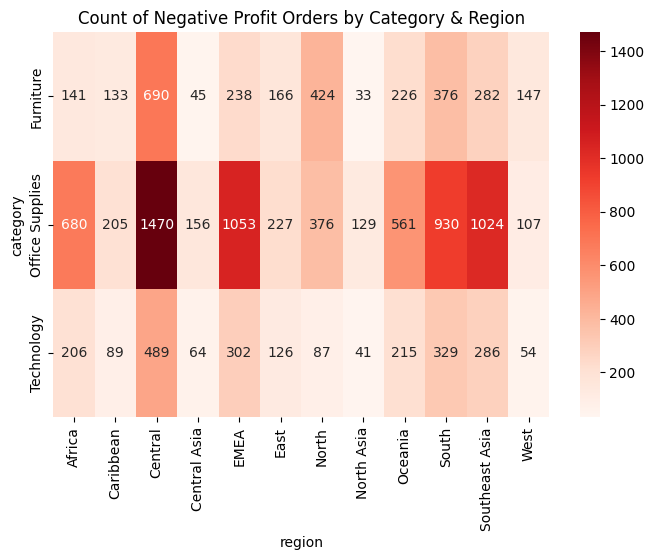

In [70]:
neg_df = df[df['profit_margin'] < 0]
pivot_neg = neg_df.pivot_table(index='category', columns='region', values='profit_margin', aggfunc='count')

plt.figure(figsize=(8,5))
sns.heatmap(pivot_neg, annot=True, fmt="d", cmap="Reds")
plt.title("Count of Negative Profit Orders by Category & Region")
plt.show()

# Profit Margin Over Time (Monthly Trend)

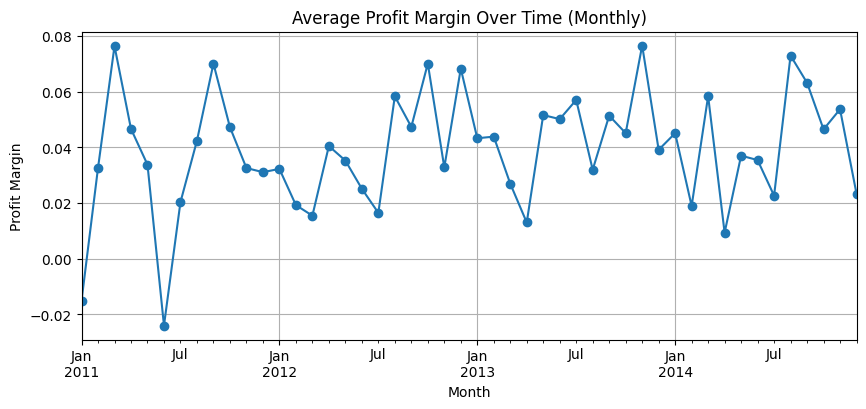

In [71]:
plt.figure(figsize=(10,4))
monthly_profit.plot(marker='o')
plt.title("Average Profit Margin Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Profit Margin")
plt.grid(True)
plt.show()

# Profit Margin vs Shipping Cost (Correlation)

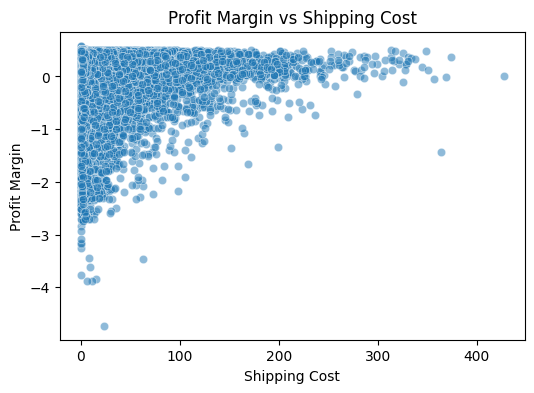

Correlation between Shipping Cost and Profit Margin: 0.07


In [72]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='shipping_cost', y='profit_margin', alpha=0.5)
plt.title("Profit Margin vs Shipping Cost")
plt.xlabel("Shipping Cost")
plt.ylabel("Profit Margin")
plt.show()

correlation = df['shipping_cost'].corr(df['profit_margin'])
print(f"Correlation between Shipping Cost and Profit Margin: {correlation:.2f}")

# Additional Insights: By Category & Region

In [73]:
print("Average Profit Margin by Category:")
print(profit_by_category)
print("\nAverage Profit Margin by Region:")
print(profit_by_region)

Average Profit Margin by Category:
category
Office Supplies    0.056964
Technology         0.033307
Furniture         -0.001175
Name: profit_margin, dtype: float64

Average Profit Margin by Region:
region
Canada            0.245238
West              0.222784
North Asia        0.177879
East              0.169768
Central Asia      0.143957
North             0.121891
Oceania           0.080064
Caribbean         0.078438
Central           0.056557
South             0.049675
Southeast Asia   -0.088479
EMEA             -0.149067
Africa           -0.156644
Name: profit_margin, dtype: float64


# Save cleaned dataset for Power BI

In [77]:
df.to_csv("PowerBI_datasets\superstore_cleaned.csv", index=False)
print("Cleaned dataset saved for Power BI!")

Cleaned dataset saved for Power BI!


# Pre-Aggregated Tables for Power BI Visuals

In [ ]:
# KPI Table (for cards)
kpi_data = {
    'Metric': ['Average Profit Margin', 'Negative Profit Orders', 'Worst Category', 'Worst Region'],
    'Value': [
        df['profit_margin'].mean(),
        len(df[df['profit_margin'] < 0]),
        df.groupby('category')['profit_margin'].mean().idxmin(),
        df.groupby('region')['profit_margin'].mean().idxmin()
    ]
}
kpi_df = pd.DataFrame(kpi_data)
kpi_df.to_csv("PowerBI_datasets\kpi_table.csv", index=False)

# Category & Region Profit Table
category_region_profit = df.groupby(['category', 'region']).agg(
    avg_profit_margin=('profit_margin', 'mean'),
    negative_orders=('profit_margin', lambda x: (x<0).sum())
).reset_index()
category_region_profit.to_csv("PowerBI_datasets\category_region_profit.csv", index=False)

# Profit Margin Over Time Table (Monthly)
monthly_profit = df.groupby(df['order_date'].dt.to_period('M')).agg(
    avg_profit_margin=('profit_margin', 'mean')
).reset_index()
monthly_profit['month_start'] = monthly_profit['order_date'].dt.to_timestamp()
monthly_profit.to_csv("PowerBI_datasets\monthly_profit.csv", index=False)

# Profit Margin vs Shipping Cost Table (for scatter plot)
profit_shipping = df[['shipping_cost', 'profit_margin']]
profit_shipping.to_csv("PowerBI_datasets\profit_shipping.csv", index=False)

print("All aggregated tables saved for Power BI!")

All aggregated tables saved for Power BI!
